# Combined EDA: PhishTank & Tranco
Exploratory data analysis on two datasets used in our phishing-detection pipeline:
1. **PhishTank** - verified phishing URLs (`../data/raw_input/verified_online.csv`)
2. **Tranco Top 1 M** - legitimate, popularity-ranked domains (`../data/raw_input/top-1m.csv`)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.parse import urlparse

We have a requirement for this assignment that it run in Google Colab. As such, we pull the repo style and data from Github first.

In [2]:
import os

# Clone the repo (skip if already present)
if not os.path.exists('DS_ML_Project_ColabIntegration'):
    !git clone https://github.com/ns15468-gasou/DS_ML_Project_ColabIntegration.git

os.chdir('DS_ML_Project_ColabIntegration/Project/notebooks')
print("Working directory:", os.getcwd())

Working directory: c:\Users\nsmith\OneDrive - Georgia Southern University\Pictures\AIFlub\DS_ML_Project_ColabIntegration\Project\notebooks


Cloning into 'DS_ML_Project_ColabIntegration'...


---
# PhishTank - Verified Phishing URLs
This section analyses the PhishTank *verified-online* feed, a curated list of confirmed phishing URLs.  
The dataset captures full URLs (scheme + host + path) along with the targeted brand and current online/offline status. [11]
**Date accessed:** 03/05/2026

In [3]:
phish = pd.read_csv('../data/raw_input/verified_online.csv')
phish['target'] = phish['target'].str.replace('&amp;', '&', regex=False)
phish.head()

,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
0,9358496,https://sgpass-fr033.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:50:49+00:00,yes,2026-03-03T20:12:24+00:00,yes,Other
1,9358495,https://sgpass-fr033.com/pages/asset.php,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:50:36+00:00,yes,2026-03-03T20:12:24+00:00,yes,Other
2,9358485,https://dervi-emprend-ec.webcindario.com/,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:27:05+00:00,yes,2026-03-03T19:32:43+00:00,yes,Other
3,9358483,https://allegro.pl-oferta1081410.sbs,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:23:57+00:00,yes,2026-03-03T19:32:43+00:00,yes,Allegro
4,9358482,http://allegrolokalnie.oferta362639327346393.sbs,http://www.phishtank.com/phish_detail.php?phis...,2026-03-03T19:23:42+00:00,yes,2026-03-03T19:32:43+00:00,yes,Allegro


In [4]:
phish.shape

(56045, 8)

# Primary Data Type Conversion

In [5]:
phish['submission_time'] = pd.to_datetime(phish['submission_time'])
phish['verification_time'] = pd.to_datetime(phish['verification_time'])
phish.dtypes

phish_id                           int64
url                               object
phish_detail_url                  object
submission_time      datetime64[ns, UTC]
verified                          object
verification_time    datetime64[ns, UTC]
online                            object
target                            object
dtype: object

## Null / Missing Value Analysis

In [6]:
phish.isnull().sum()

phish_id             0
url                  0
phish_detail_url     0
submission_time      0
verified             0
verification_time    0
online               0
target               0
dtype: int64

In [7]:
(phish == '').sum()

phish_id             0
url                  0
phish_detail_url     0
submission_time      0
verified             0
verification_time    0
online               0
target               0
dtype: int64

## Target Brand Distribution and Outlier Discussion

In [8]:
target_counts = phish['target'].value_counts().head(15)
print(target_counts)

target
Other                                  52773
Internal Revenue Service                 814
Allegro                                  654
Facebook                                 319
Microsoft                                185
Optus                                    147
DHL                                      102
AT&T                                      77
Sumitomo Mitsui Banking Corporation       75
Amazon.com                                67
Bradesco                                  62
Netflix                                   61
PayPal                                    57
Adobe                                     47
eBay, Inc.                                41
Name: count, dtype: int64


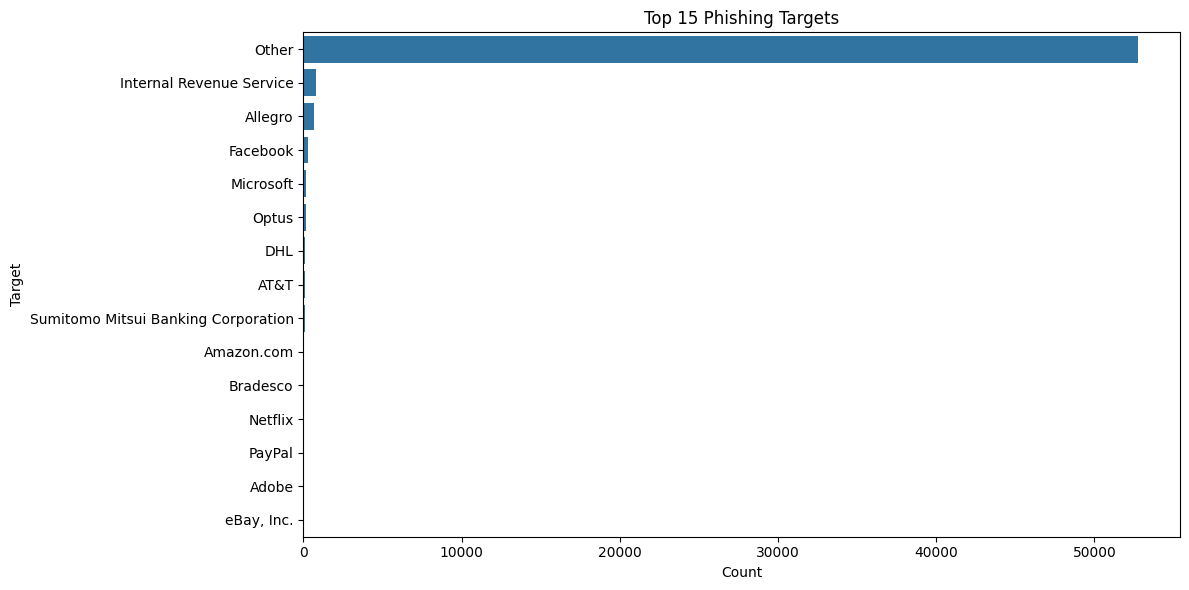

In [9]:
plt.figure(figsize=(12,6))
sns.barplot(x=target_counts.values, y=target_counts.index)
plt.title('Top 15 Phishing Targets')
plt.xlabel('Count')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

* "Other" accounts for the vast majority of targets. "Other" is excluded in the below chart but note this represents a small fraction of the full dataset.

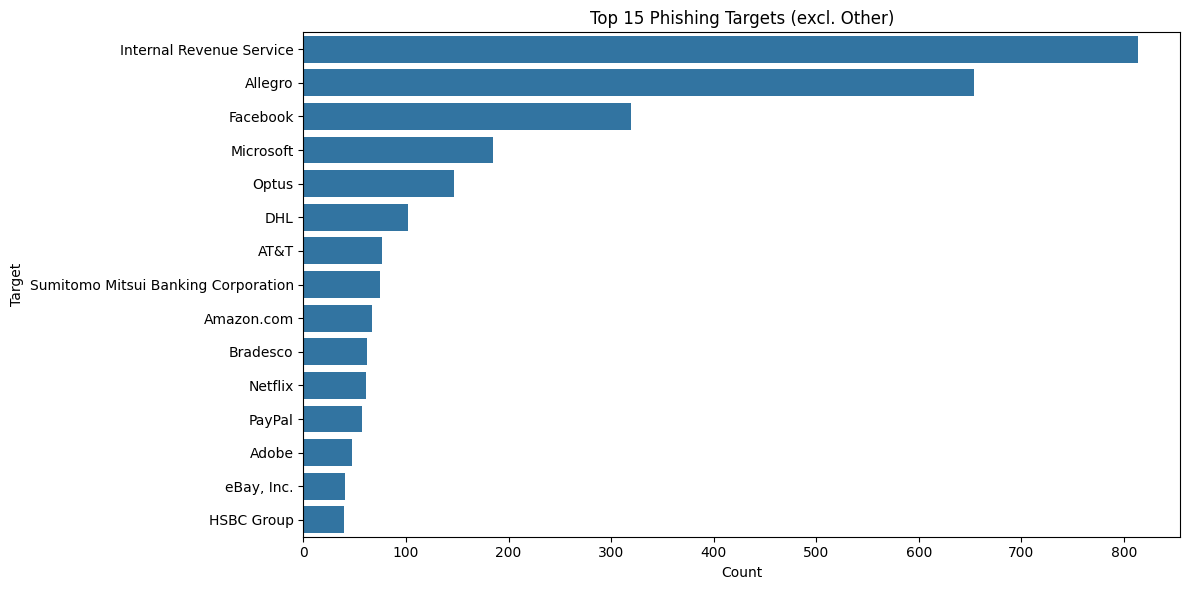

In [10]:
target_counts_filtered = phish[phish['target'] != 'Other']['target'].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=target_counts_filtered.values, y=target_counts_filtered.index)
plt.title('Top 15 Phishing Targets (excl. Other)')
plt.xlabel('Count')
plt.ylabel('Target')
plt.tight_layout()
plt.show()

## Online vs Offline Breakdown

online
yes    56045
Name: count, dtype: int64


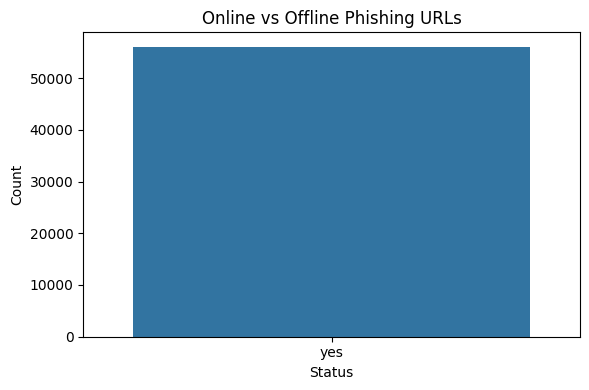

In [11]:
online_counts = phish['online'].value_counts()
print(online_counts)

plt.figure(figsize=(6,4))
sns.barplot(x=online_counts.index, y=online_counts.values)
plt.title('Online vs Offline Phishing URLs')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Dataset Limitations
This dataset is only the verified online feed, meaning this dataset is a subset of the greater PhishTank dataset. Future work could expand to use the full dataset. This dataset would be great for clustering/unsupervised ML work: the dominance of 'Other' in the target category shows the opportunity to clean/mine this data for meaningful categorization.

## URL Structure Analysis and Feature Expansion
Feature engineering and visualizations on URL structure - length, hosting domains, path depth, and character composition.

In [12]:
phish['host'] = phish['url'].apply(lambda x: urlparse(x).netloc.lower())
phish['full_length'] = phish['url'].str.len()
phish['host_length'] = phish['host'].str.len()
phish['path'] = phish['url'].apply(lambda x: urlparse(x).path)
phish['path_depth'] = phish['path'].apply(lambda p: p.strip('/').count('/') + 1 if p.strip('/') else 0)
phish['has_path'] = (phish['path'].str.strip('/') != '').astype(int)
phish['tld_ext'] = phish['host'].str.rsplit('.', n=1).str[-1]
phish['dot_count'] = phish['url'].str.count(r'\.')
phish['hyphen_count'] = phish['url'].str.count('-')
phish['digit_count'] = phish['url'].str.count(r'\d')
phish['digit_ratio'] = phish['digit_count'] / phish['full_length']
phish['subdomain_depth'] = phish['host'].str.count(r'\.')

phish[['full_length', 'host_length', 'path_depth', 'dot_count', 'hyphen_count',
    'digit_count', 'digit_ratio', 'subdomain_depth']].describe()

,full_length,host_length,path_depth,dot_count,hyphen_count,digit_count,digit_ratio,subdomain_depth
count,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000,56045.000000
mean,60.922866,19.275511,1.387457,1.974413,0.797127,6.373254,0.075019,1.768454
std,166.386061,12.977728,1.582218,1.025418,1.391185,24.004548,0.096198,0.583268
min,12.000000,4.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,23.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,38.000000,16.000000,1.000000,2.000000,0.000000,1.000000,0.045455,2.000000
75%,62.000000,25.000000,2.000000,2.000000,1.000000,8.000000,0.107143,2.000000
max,25523.000000,147.000000,18.000000,67.000000,50.000000,3413.000000,0.796610,9.000000


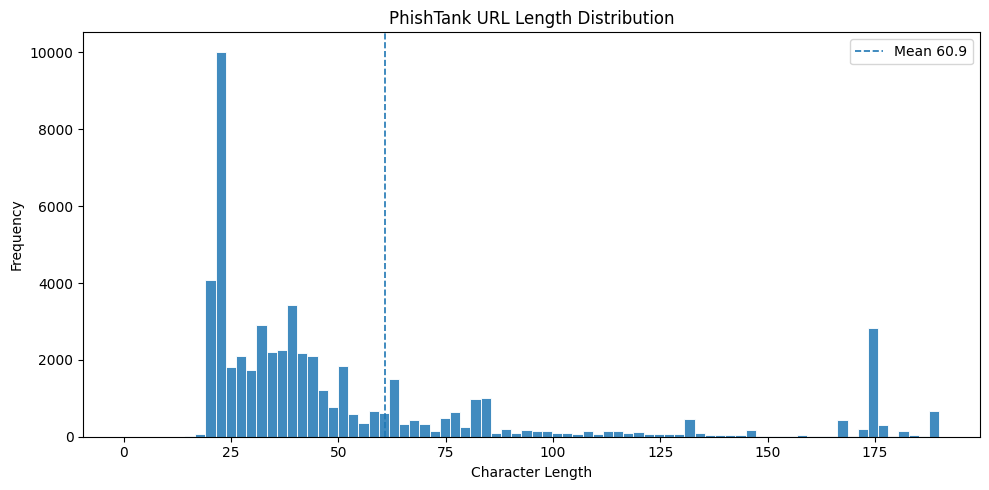

In [13]:
# URL length distribution (clipped to 98th percentile)
plt.figure(figsize=(10, 5))
sns.histplot(phish['full_length'], bins=80, edgecolor='white', alpha=0.85,
             binrange=(0, phish['full_length'].quantile(0.98)))
plt.axvline(phish['full_length'].mean(), ls='--', lw=1.2,
            label=f'Mean {phish["full_length"].mean():.1f}')
plt.title('PhishTank URL Length Distribution')
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.legend()
plt.show()

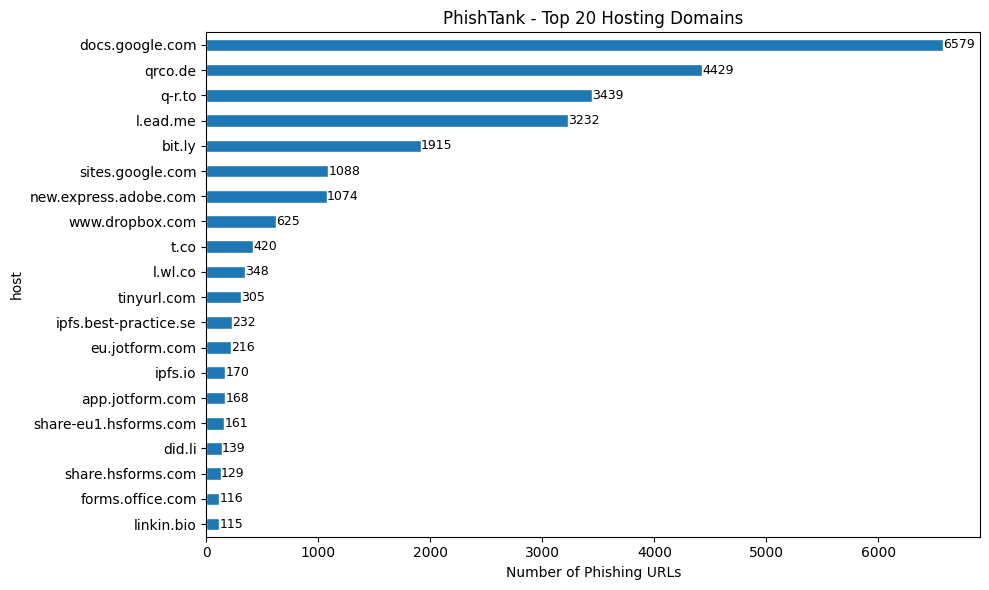

In [14]:
# Top 20 hosting domains
host_counts = phish['host'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 6))
host_counts.plot.barh(ax=ax, edgecolor='white')
ax.set_title('PhishTank - Top 20 Hosting Domains')
ax.set_xlabel('Number of Phishing URLs')
ax.invert_yaxis()

for i, v in enumerate(host_counts):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

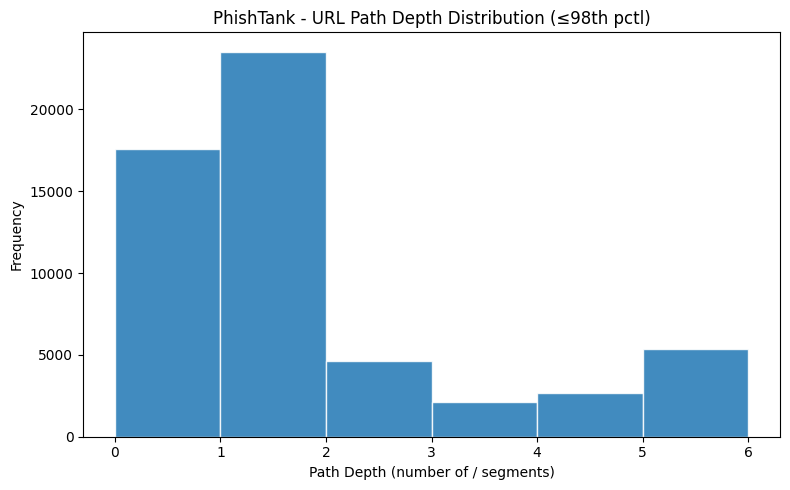

In [15]:
# Path depth distribution (clipped to 98th percentile)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(phish['path_depth'],
        bins=range(0, int(phish['path_depth'].quantile(0.98)) + 2),
        edgecolor='white', alpha=0.85)
ax.set_title('PhishTank - URL Path Depth Distribution (≤98th pctl)')
ax.set_xlabel('Path Depth (number of / segments)')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

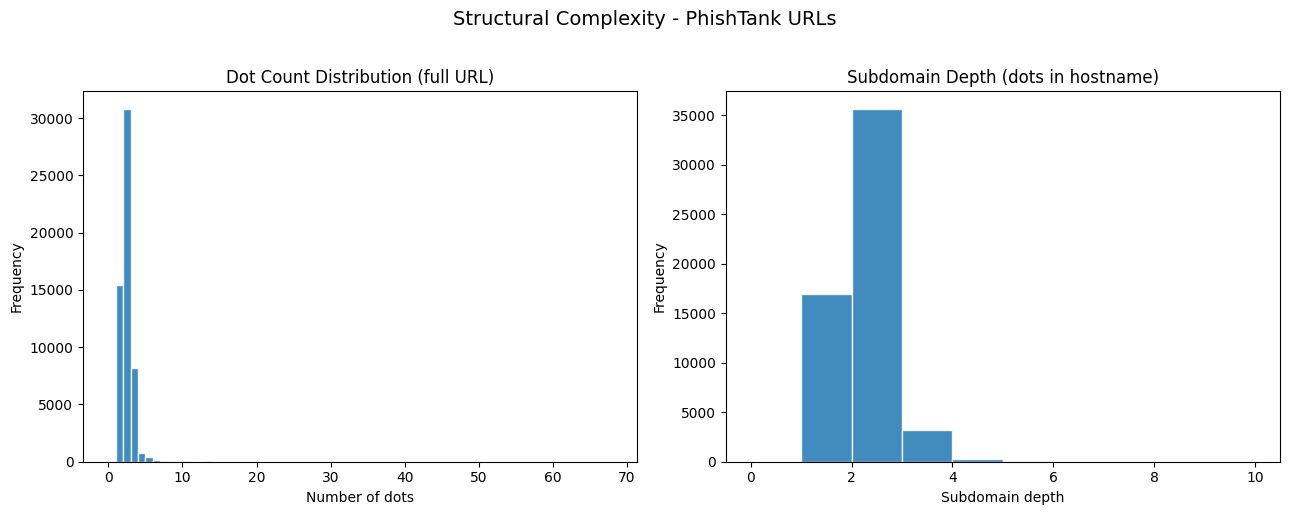

In [16]:
# Structural complexity: dot count & subdomain depth
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(phish['dot_count'], bins=range(0, phish['dot_count'].max() + 2),
             edgecolor='white', alpha=0.85)
axes[0].set_title('Dot Count Distribution (full URL)')
axes[0].set_xlabel('Number of dots')
axes[0].set_ylabel('Frequency')

axes[1].hist(phish['subdomain_depth'], bins=range(0, phish['subdomain_depth'].max() + 2),
             edgecolor='white', alpha=0.85)
axes[1].set_title('Subdomain Depth (dots in hostname)')
axes[1].set_xlabel('Subdomain depth')
axes[1].set_ylabel('Frequency')

fig.suptitle('Structural Complexity - PhishTank URLs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

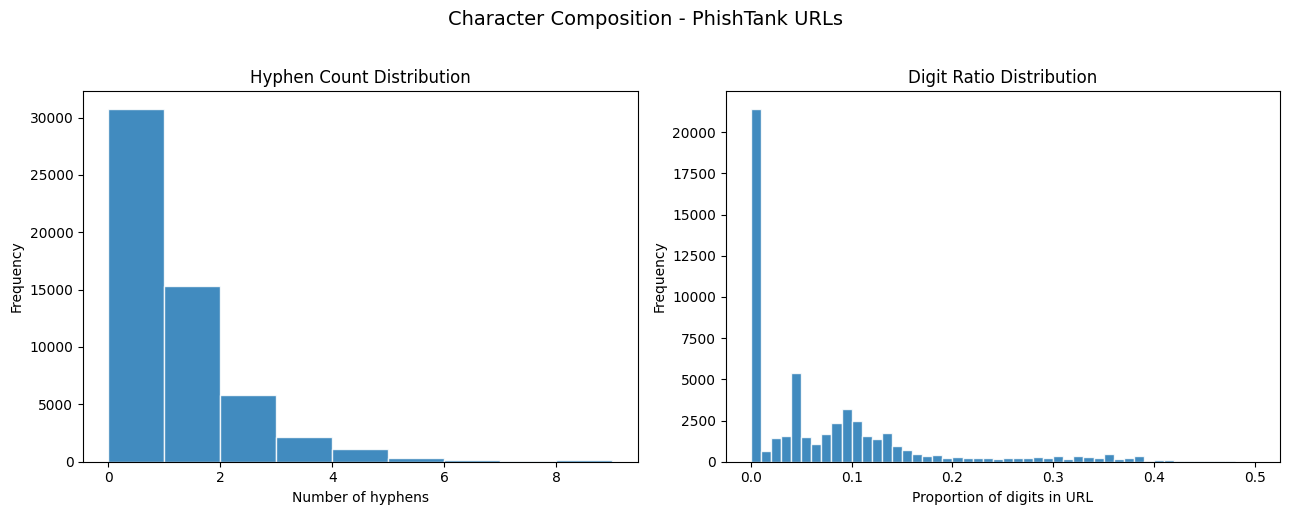

In [17]:
# Character composition: hyphens & digit ratio
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(phish['hyphen_count'], bins=range(0, 10),
             edgecolor='white', alpha=0.85)
axes[0].set_title('Hyphen Count Distribution')
axes[0].set_xlabel('Number of hyphens')
axes[0].set_ylabel('Frequency')

axes[1].hist(phish['digit_ratio'], bins=50,
              edgecolor='white', alpha=0.85, range=(0, 0.5))
axes[1].set_title('Digit Ratio Distribution')
axes[1].set_xlabel('Proportion of digits in URL')
axes[1].set_ylabel('Frequency')

fig.suptitle('Character Composition - PhishTank URLs', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Data Normalization/Scaling Notice
Data normalization is normally done to allow ML models to interact with features that aren't already normally distributed. However, we do not do such normalization on the raw data, but rather the semantic modeling of the data in the final stages of this notebook. We are focused on the semantic insights we can gleam from ML, so normalization occurs there.

---
# Tranco - Top 1 M Legitimate Domains
This section analyses the Tranco Top-1M ranking, an aggregated popularity list of legitimate domains.  
Unlike PhishTank URLs, Tranco entries are bare domains (no scheme or path), making structural features directly comparable at the hostname level.
Cisco provides resources to help massage all the data coming in [10].

**List ID:** 6GPNX &nbsp;|&nbsp; **Date accessed:** 03/05/2026

In [18]:
tranco = pd.read_csv('../data/raw_input/top-1m.csv', header=None, names=['rank', 'domain'])
tranco.head()

,rank,domain
0,1,google.com
1,2,microsoft.com
2,3,gtld-servers.net
3,4,facebook.com
4,5,mail.ru


In [19]:
tranco.shape

(1000000, 2)

In [20]:
tranco.dtypes

rank       int64
domain    object
dtype: object

## Null / Missing Value Analysis

In [21]:
tranco.isnull().sum()

(tranco == '').sum()

rank      0
domain    0
dtype: int64

## Duplicate Check

In [22]:
duplicateDomains = tranco['domain'].duplicated().sum()
duplicateRanks = tranco['rank'].duplicated().sum()
print(f'Duplicate domains: {duplicateDomains}')
print(f'Duplicate ranks: {duplicateRanks}')

Duplicate domains: 0
Duplicate ranks: 0


# Feature Engineering and Feature Distributions
## Top Level Domains:

In [23]:
tranco['tld'] = tranco['domain'].str.split('.').str[-1]
tld_counts = tranco['tld'].value_counts().head(15)
print(tld_counts)

tld
com    431460
net     51741
ru      42879
org     39514
de      26817
uk      22815
br      17524
jp      16280
in      12403
fr      11433
io      10800
nl      10241
it      10051
xyz      9407
pl       9054
Name: count, dtype: int64


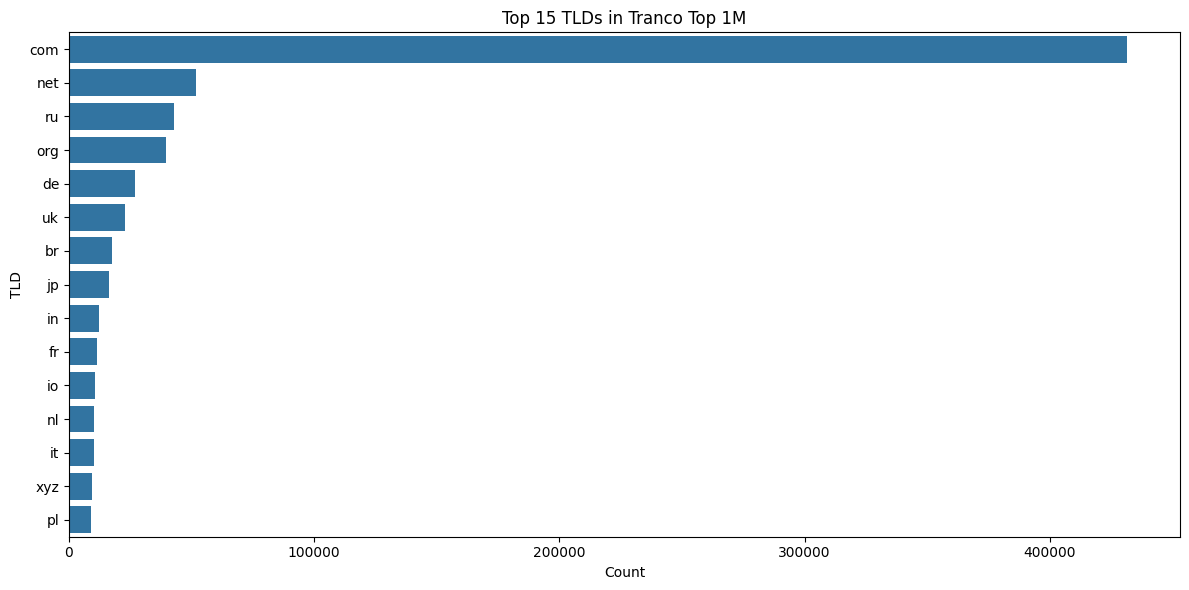

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(x=tld_counts.values, y=tld_counts.index)
plt.title('Top 15 TLDs in Tranco Top 1M')
plt.xlabel('Count')
plt.ylabel('TLD')
plt.tight_layout()
plt.show()

## Domain Length Distribution and Outlier Discussions

In [25]:
tranco['domain_length'] = tranco['domain'].str.len()
print(tranco['domain_length'].describe())

count    1000000.000000
mean          13.739423
std            4.346079
min            4.000000
25%           11.000000
50%           13.000000
75%           16.000000
max           75.000000
Name: domain_length, dtype: float64


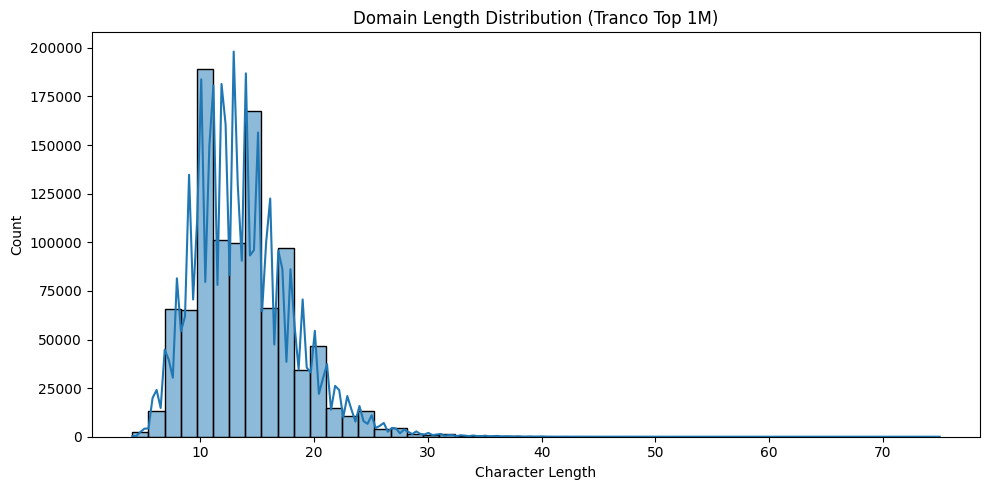

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(tranco['domain_length'], bins=50, kde=True)
plt.title('Domain Length Distribution (Tranco Top 1M)')
plt.xlabel('Character Length')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Structural & Character Features
Dot counts, subdomain depth, hyphens, and digit ratios for Tranco domains.

In [27]:
tranco['dot_count'] = tranco['domain'].str.count(r'\.')
tranco['hyphen_count'] = tranco['domain'].str.count('-')
tranco['digit_count'] = tranco['domain'].str.count(r'\d')
tranco['digit_ratio'] = tranco['digit_count'] / tranco['domain_length']
tranco['subdomain_depth'] = tranco['domain'].str.count(r'\.')

tranco[['domain_length', 'dot_count', 'hyphen_count', 'digit_count', 'digit_ratio', 'subdomain_depth']].describe()

,domain_length,dot_count,hyphen_count,digit_count,digit_ratio,subdomain_depth
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,13.739423,1.107173,0.121737,0.275257,0.022526,1.107173
std,4.346079,0.314686,0.410282,0.936712,0.075484,0.314686
min,4.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,11.000000,1.000000,0.000000,0.000000,0.000000,1.000000
50%,13.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,16.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,75.000000,3.000000,11.000000,56.000000,0.933333,3.000000


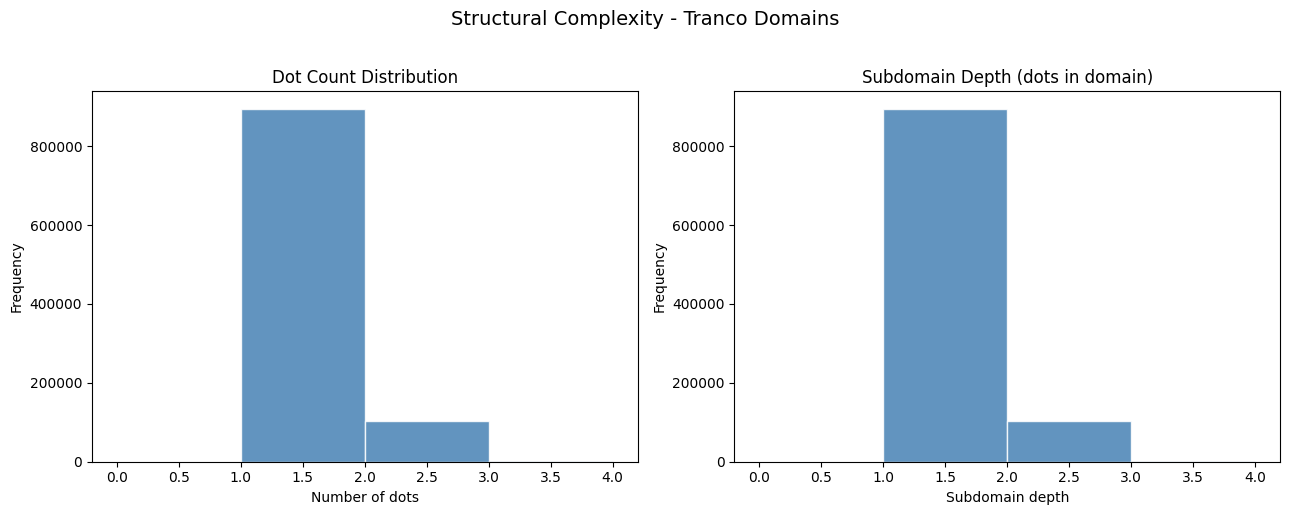

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bins_dots = range(0, tranco['dot_count'].max() + 2)
axes[0].hist(tranco['dot_count'], bins=bins_dots, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Dot Count Distribution')
axes[0].set_xlabel('Number of dots')
axes[0].set_ylabel('Frequency')

bins_sub = range(0, tranco['subdomain_depth'].max() + 2)
axes[1].hist(tranco['subdomain_depth'], bins=bins_sub, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Subdomain Depth (dots in domain)')
axes[1].set_xlabel('Subdomain depth')
axes[1].set_ylabel('Frequency')

fig.suptitle('Structural Complexity - Tranco Domains', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

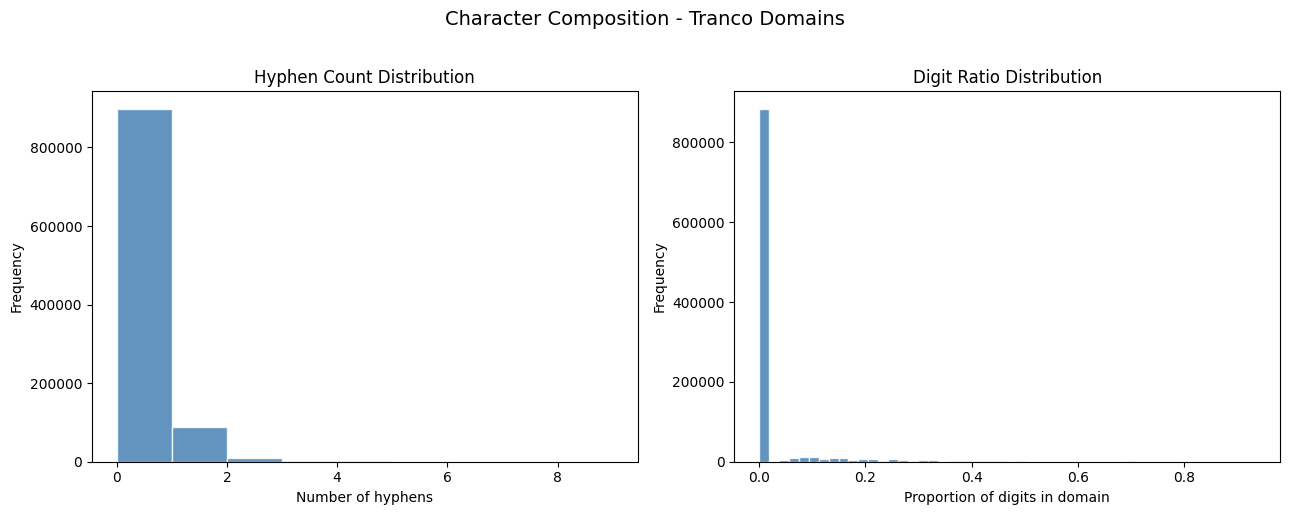

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(tranco['hyphen_count'], bins=range(0, 10), color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Hyphen Count Distribution')
axes[0].set_xlabel('Number of hyphens')
axes[0].set_ylabel('Frequency')

axes[1].hist(tranco['digit_ratio'], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title('Digit Ratio Distribution')
axes[1].set_xlabel('Proportion of digits in domain')
axes[1].set_ylabel('Frequency')

fig.suptitle('Character Composition - Tranco Domains', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# Cross-Dataset Analysis

## PhishTank / Tranco Overlap

In [30]:
phish['domain'] = phish['url'].apply(lambda x:
    urlparse(x).netloc.lower().replace('www.', '', 1))

tranco_domains = set(tranco['domain'].str.lower())
overlap = phish['domain'].isin(tranco_domains).sum()
print(f'Phishing URLs whose domain appears in Tranco Top 1M: {overlap} / {len(phish)} ({overlap/len(phish)*100:.2f}%)')

Phishing URLs whose domain appears in Tranco Top 1M: 13662 / 56045 (24.38%)


In [31]:
print(f"Tranco: {len(tranco):,} legitimate domains (ranked by popularity)")
print(f"PhishTank: {len(phish):,} verified phishing URLs")
print(f"Overlap: {overlap:,} phishing domains found in Tranco top 1M ({overlap/len(phish)*100:.2f}%)")
print("\nNotes:\n- Tranco aggregates multiple blocklists/popularity sources; high rank != guaranteed safe\n- PhishTank is a snapshot of verified-online phishing URLs, not exhaustive\n- Overlap may reflect compromised legitimate domains or shared hosting infrastructure")


Tranco: 1,000,000 legitimate domains (ranked by popularity)
PhishTank: 56,045 verified phishing URLs
Overlap: 13,662 phishing domains found in Tranco top 1M (24.38%)

Notes:
- Tranco aggregates multiple blocklists/popularity sources; high rank != guaranteed safe
- PhishTank is a snapshot of verified-online phishing URLs, not exhaustive
- Overlap may reflect compromised legitimate domains or shared hosting infrastructure


## Summary Comparison Table
Side-by-side comparison of Tranco legitimate domains vs PhishTank phishing URLs.

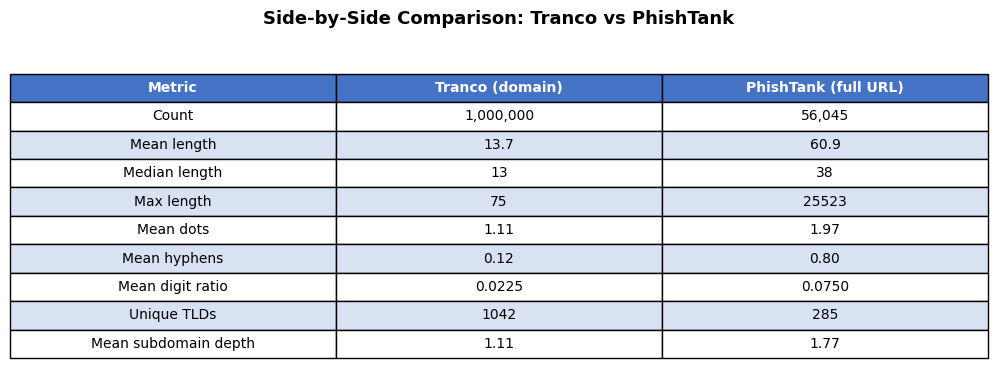

In [32]:
summary_data = {
    "Metric": [
        "Count", "Mean length", "Median length", "Max length",
        "Mean dots", "Mean hyphens", "Mean digit ratio",
        "Unique TLDs", "Mean subdomain depth"
    ],
    "Tranco (domain)": [
        f"{len(tranco):,}",
        f"{tranco['domain_length'].mean():.1f}",
        f"{tranco['domain_length'].median():.0f}",
        f"{tranco['domain_length'].max()}",
        f"{tranco['dot_count'].mean():.2f}",
        f"{tranco['hyphen_count'].mean():.2f}",
        f"{tranco['digit_ratio'].mean():.4f}",
        f"{tranco['tld'].nunique()}",
        f"{tranco['subdomain_depth'].mean():.2f}",
    ],
    "PhishTank (full URL)": [
        f"{len(phish):,}",
        f"{phish['full_length'].mean():.1f}",
        f"{phish['full_length'].median():.0f}",
        f"{phish['full_length'].max()}",
        f"{phish['dot_count'].mean():.2f}",
        f"{phish['hyphen_count'].mean():.2f}",
        f"{phish['digit_ratio'].mean():.4f}",
        f"{phish['tld_ext'].nunique()}",
        f"{phish['subdomain_depth'].mean():.2f}",
    ],
}
summary_tbl = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
tbl = ax.table(cellText=summary_tbl.values, colLabels=summary_tbl.columns,
               loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
for (row, col), cell in tbl.get_celld().items(): # From Datacamp [9], alternating row colors and header styling
    if row == 0:
        cell.set_facecolor("#4472C4")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#D9E2F3")
ax.set_title("Side-by-Side Comparison: Tranco vs PhishTank", fontsize=13,
             fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## Correlation Heatmaps
Pearson correlation among the numerical structural features for each dataset.  
Since Tranco entries are bare domains and PhishTank entries are full URLs, each heatmap uses the features native to its dataset.

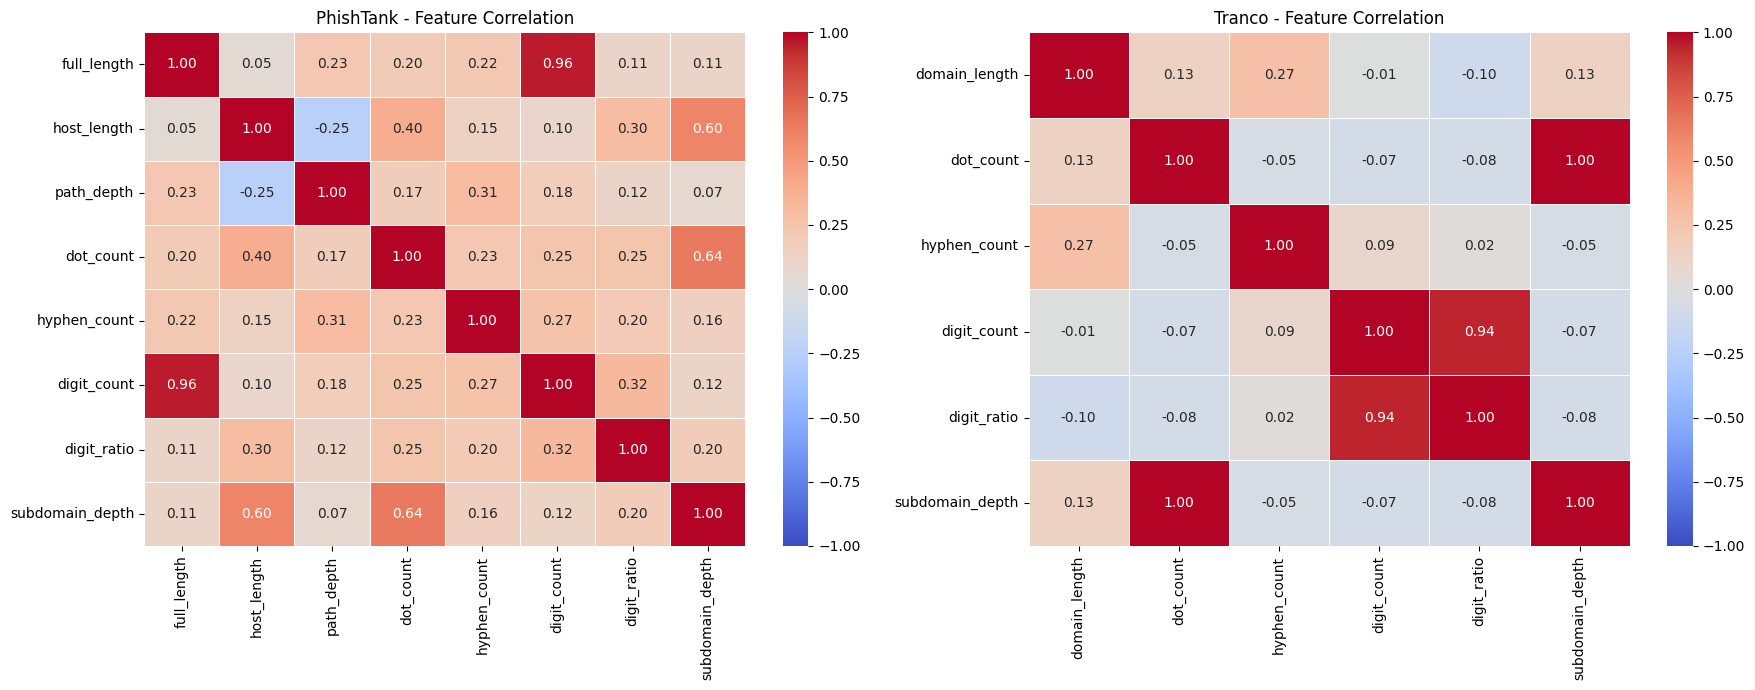


PhishTank - Top 3 strongest correlations:
  full_length ↔ digit_count: r = 0.957
  dot_count ↔ subdomain_depth: r = 0.643
  host_length ↔ subdomain_depth: r = 0.599

Tranco - Top 3 strongest correlations:
  dot_count ↔ subdomain_depth: r = 1.000
  digit_count ↔ digit_ratio: r = 0.945
  domain_length ↔ hyphen_count: r = 0.274


In [33]:
phish_num = phish[['full_length', 'host_length', 'path_depth', 'dot_count',
                   'hyphen_count', 'digit_count', 'digit_ratio', 'subdomain_depth']]
tranco_num = tranco[['domain_length', 'dot_count', 'hyphen_count',
                     'digit_count', 'digit_ratio', 'subdomain_depth']]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PhishTank heatmap
corr_phish = phish_num.corr()
sns.heatmap(corr_phish, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('PhishTank - Feature Correlation', fontsize=12)

# Tranco heatmap
corr_tranco = tranco_num.corr()
sns.heatmap(corr_tranco, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Tranco - Feature Correlation', fontsize=12)

plt.tight_layout()
plt.show()

# Interpret strongest correlations for each dataset
for name, corr in [('PhishTank', corr_phish), ('Tranco', corr_tranco)]:
    # Upper triangle only (no duplicates / diagonal)
    mask = pd.np.triu(pd.np.ones(corr.shape), k=1).astype(bool) if hasattr(pd, 'np') else __import__('numpy').triu(__import__('numpy').ones(corr.shape), k=1).astype(bool)
    pairs = corr.where(mask).stack().reset_index()
    pairs.columns = ['Feature A', 'Feature B', 'r']
    pairs['abs_r'] = pairs['r'].abs()
    top = pairs.nlargest(3, 'abs_r')
    print(f"\n{name} - Top 3 strongest correlations:")
    for _, row in top.iterrows():
        print(f"  {row['Feature A']} ↔ {row['Feature B']}: r = {row['r']:.3f}")

## Scatter Plots - Feature Relationships
Pair plots of key structural features for each dataset to visualize bivariate relationships.

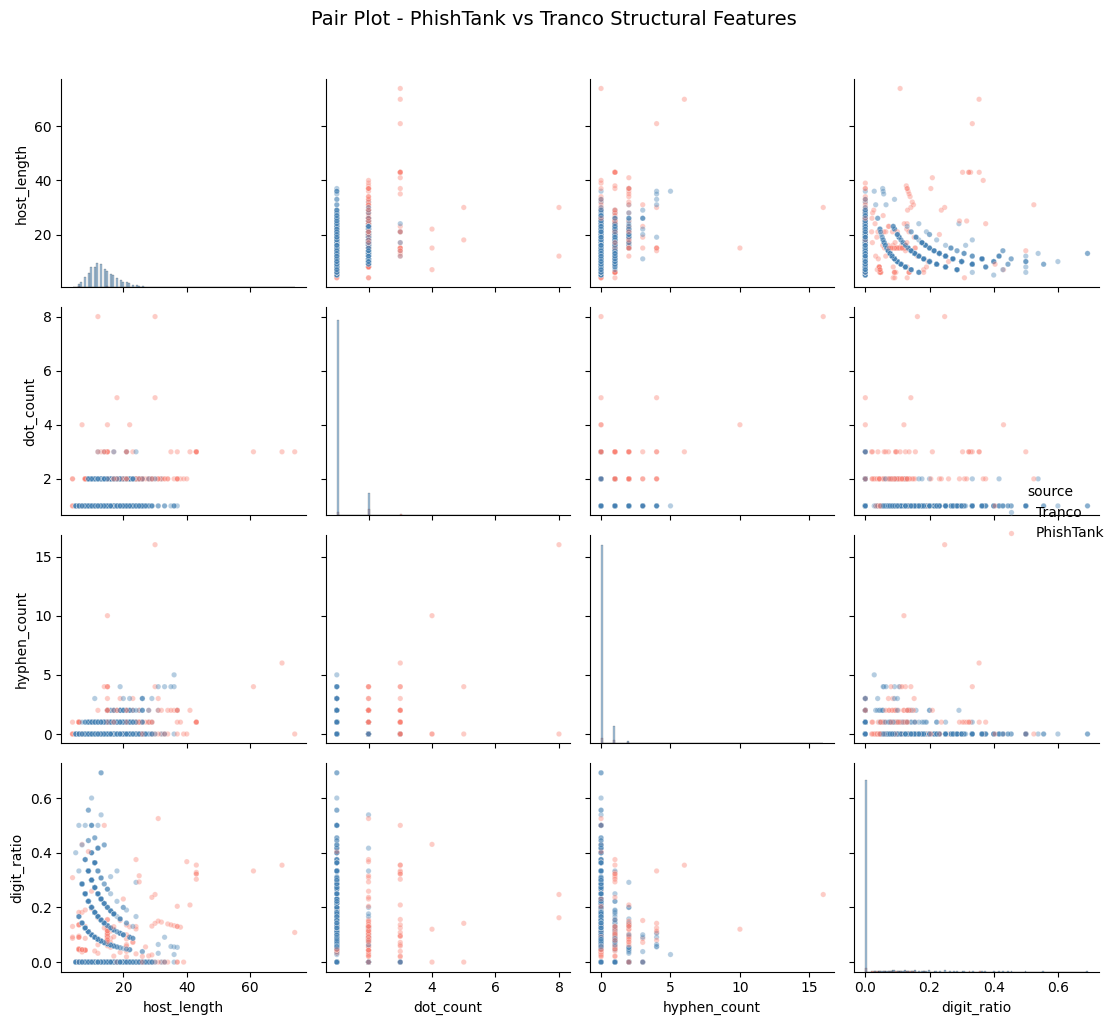

In [34]:
import numpy as np

# Build a combined dataframe with a 'source' label as a target variable
phish_sample = phish[['host_length', 'dot_count', 'hyphen_count', 'digit_ratio', 'subdomain_depth']].copy()
phish_sample['source'] = 'PhishTank'

tranco_sample = tranco[['domain_length', 'dot_count', 'hyphen_count', 'digit_ratio', 'subdomain_depth']].copy()
tranco_sample = tranco_sample.rename(columns={'domain_length': 'host_length'})
tranco_sample['source'] = 'Tranco'

combined = pd.concat([phish_sample, tranco_sample], ignore_index=True)

# Pair plot colored by dataset source
g = sns.pairplot(combined.sample(n=min(4000, len(combined)), random_state=42),
                 hue='source', vars=['host_length', 'dot_count', 'hyphen_count', 'digit_ratio'],
                 diag_kind='hist', plot_kws={'alpha': 0.4, 's': 15},
                 palette={'PhishTank': 'salmon', 'Tranco': 'steelblue'})
g.figure.suptitle('Pair Plot - PhishTank vs Tranco Structural Features', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## Export Processed Datasets

In [35]:
phish.to_csv('../data/processed_input/phishtank_cleaned.csv', index=False)
tranco.to_csv('../data/processed_input/tranco_cleaned.csv', index=False)
print("Exported phishtank_cleaned.csv and tranco_cleaned.csv.")

Exported phishtank_cleaned.csv and tranco_cleaned.csv.


Success.

# Major Notice before Semantic Data Pull
After cleaning the above data, the last step needed before ML analysis is to represent the *semantic* meaning of the words via text embeddings.

We have done lexical analysis with pieces like URL length, but we need semantic meanings to be able to get at the root of our research question, to learn if semantic mining of information from IoCs can provide novel results.

Unfortunately, we cannot include the embedding step into this monolithic ipynb, as the cutting edge embeddings API we used ("gemini-embedding-001") is not freely available. We are able to use student credits for it, but not able to put it in a shared Colab our professor can run. To verify our work, you can look at the file `embed_data_pipeline.ipynb` in the repo, and that annotates more deeply how we got the embedded dataset for the above domains. But for actual access to the embedding algorithm, it is not shareable, only its outputs.

Additionally, know that with the amount of dimensions and rows (3072 dimensional vectors with 50,000 * 50,000 datapoints), this took a long time to run on colab. An hour or two should be set aside for computing all the similarities to be processed.

# Cosine Similarity Pipeline

This notebook combines two phases of the phishing-domain similarity analysis process:
1. **Part A - Computing Cosine Similarity** (`cosine_similarity.py`):  
   Loads PhishTank and Tranco embedding files, computes a cosine-similarity matrix, and saves the matrix to CSV. We generated embeddings data using the Google Gemini embeddings API and process those embeddings here.  
   Embeddings are useful for semantic IoC analysis because they map related indicators (e.g., lookalike domains, phishing-themed terms, or similar URL patterns) close together in vector space, helping detect meaningful relationships beyond exact string matches. We will analyze that vector space in ML after processing the embeddings.

2. **Part B - Extract Top-5 from a Pre-computed Matrix** (`top5_from_matrix.py`):  
   Streams the ~23GB of pre-existing matrix data (`FullMatrixOfCosineSimil.csv`) line-by-line and extract the top-5 most similar items per row **and** per column, keeping memory usage low. This matrix allows base level EDA and analysis to happen much easier.

---

## Imports

All libraries needed by both stages are loaded here.  

In [3]:
# standard-library I/O
import csv
import json
import sys
import gc

# use min-heap for priority queue when choosing top-N matches
import heapq

# safe path handling across ipynb and Google resources
from pathlib import Path

# cosine similarity and other vector operations
import numpy as np

# used to easily export to CSV and handle dataframes
import pandas as pd

We have a requirement for this assignment that it run in Google Colab. As such, we pull the repo style and data from Github first.

## Configuration

All our file paths and constants are defined in one place so they are easy to update.  
`BASE_DIR` is set to the directory containing this notebook for local running.
When embedding, I hit the limit of the 16GB of RAM on my machine, so the layout of the data is as follows:

embeds1 == 1st half of PhishTank Embeddings
embeds2 == 2nd half of PhishTank Embeddings
embedsA == All Tranco Embeddings

In [4]:
BASE_DIR = Path.cwd().parent  # one level up from notebook cwd
DATA_DIR = BASE_DIR / "data"  # ../data

# Part A I/O
EMBEDS1_FILE = DATA_DIR / "embeds1.csv"
EMBEDS2_FILE = DATA_DIR / "embeds2.csv"
EMBEDSA_FILE = DATA_DIR / "embedsA.csv"
OUT_MATRIX   = DATA_DIR / "FullMatrixOfCosineSimil.csv"

# Part B I/O
FULL_MATRIX_FILE = DATA_DIR / "FullMatrixOfCosineSimil.csv"
OUT_ROW          = DATA_DIR / "top5_per_row.csv"
OUT_COL          = DATA_DIR / "top5_per_column.csv"

TOP_N = 5 # Used if we wanted to test more or fewer top matches

### Download Embedding Files from Cloud Storage

The three embedding CSVs are each multiple gigabytes, but we also have to allow the professor to run our data analysis.  
As such, they are streamed in 8 MB chunks so memory stays bounded during the download.  
Files that already exist on disk are skipped.

In [38]:
import urllib.request
import shutil

_GCS_BASE = "https://storage.googleapis.com/gscsteam1-colabresultbucket"
_EMBED_FILES = {
    EMBEDS1_FILE: f"{_GCS_BASE}/embeds1.csv",
    EMBEDS2_FILE: f"{_GCS_BASE}/embeds2.csv",
    EMBEDSA_FILE: f"{_GCS_BASE}/embedsA.csv",
}

for local_path, url in _EMBED_FILES.items():
    if local_path.exists():
        print(f"  Already exists, skipping: {local_path.name}")
        continue
    print(f"  Downloading {local_path.name} …", flush=True)
    local_path.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(url) as resp, open(local_path, "wb") as out:
        shutil.copyfileobj(resp, out, length=8 * 1024 * 1024)  # 8 MB chunks
    size_gb = local_path.stat().st_size / 1e9
    print(f"    Done ({size_gb:.2f} GB)")

print("All embedding files ready.")

    Done (2.91 GB)
    Done (1.28 GB)
    Done (3.46 GB)
All embedding files ready.


---
# Part A - Compute Cosine Similarity from Raw Embeddings

As mentioned earlier, Phishtank took up too much memory. As such, we combine 2 sets of their embeddings
(`embeds1` + `embeds2`), deduplicate them, and then compute their cosine similarity against a third set (`embedsA`).  
The outputted result is a full N×M matrix plus a handy top-5 summary.

### Helper Function - `load_embeddings`

Reads a CSV whose rows are `(embedding_json_array, text_label)`.  
Returns a dict `{text_label: embedding_vector}`, keeping only the first  
occurrence of each label.

This deduplicates the data by keeping a sort of running tally for rows.

In [39]:
def load_embeddings(filepath: Path) -> dict[str, np.ndarray]:
    """Load a CSV embeddings file (embedding,text), returning {text: embedding_vector}.
    Vectors are stored as np.float32 arrays to cut memory ~7x vs Python lists."""
    result = {}
    with open(filepath, "r", encoding="utf-8", newline="") as f:
        reader = csv.reader(f)
        next(reader, None)  # skip header row (embedding,text)
        for row in reader:
            if len(row) < 2:
                continue
            embedding_str, name = row[0], row[1]
            if name not in result:  # keep first occurrence
                result[name] = np.array(json.loads(embedding_str), dtype=np.float32)
    return result

### Helper - `build_matrix`

Converts the `{name: vector}` dictionary into a NumPy float32 matrix  
and the corresponding ordered list of names.  
This is needed so we can use fast vectorised operations for Cosine Similarity.
This approach was ellucidated from the work of Saidani, cited in our paper [5].

In [40]:
def build_matrix(app_dict: dict[str, list[float]]) -> tuple[list[str], np.ndarray]:
    """Convert {name: vector} dict to (name_list, numpy_matrix)."""
    names = list(app_dict.keys())
    mat = np.array([app_dict[n] for n in names], dtype=np.float32)
    return names, mat

### Helper - `cosine_similarity_matrix`

Computes the pairwise cosine similarity between two sets of vectors  
using the efficient **normalise → matmul** approach:

$$
\text{sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \, \|\mathbf{b}\|}
$$

By L2-normalising each row first, the dot product of the resulting  
unit vectors directly yields cosine similarity. This basic utilization of Cosine Similarity is taken from Sonowal and Gunikhan [6].

In [41]:
def cosine_similarity_matrix(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """
    Compute cosine similarity between every row in A and every row in B.
    Returns shape (len(A), len(B)).
    """
    A_norm = A / np.linalg.norm(A, axis=1, keepdims=True)
    B_norm = B / np.linalg.norm(B, axis=1, keepdims=True)
    return A_norm @ B_norm.T

### Step A1 - Load & Deduplicate Embeddings

Load `embeds1.csv` and `embeds2.csv`, merge them (with `embeds1` "winning"
on name collisions), and then load `embedsA.csv` separately.

In [42]:
print("Loading embeddings files")
emb1 = load_embeddings(EMBEDS1_FILE)
emb2 = load_embeddings(EMBEDS2_FILE)

# Merge: emb1 takes precedence; add only new keys from emb2
combined = {}
for name, vec in emb1.items():
    combined[name] = vec
for name, vec in emb2.items():
    if name not in combined:
        combined[name] = vec
del emb1, emb2  # free memory
gc.collect()

print(f"  Combined & deduplicated: {len(combined)} unique entries\n")

embA = load_embeddings(EMBEDSA_FILE)

Loading embeddings files
  Combined & deduplicated: 55625 unique entries



### Step A1.5 - Additional Data Cleaning & Deduplication of URLs

Before converting to NumPy arrays, we normalise every URL key by stripping
the scheme (`http://`, `https://`), a leading `www.`, and any trailing `/`.
Two URLs that differ only in these prefixes or suffixes will now map to the
same key, so we deduplicate one more time (keeping the first occurrence).

This is applied to **both** the merged PhishTank embeddings (`combined`)
and the Tranco embeddings (`embA`).

A reversible mapping CSV (`url` → `cleaned_url`) is saved for each dataset
so the original URLs can be recovered later. The `url` column is unique;
`cleaned_url` may contain duplicates where multiple originals collapsed to
the same normalised key.

This additional data had some use during the EDA phase and embedding phase (as things like HTTP vs HTTPS can imply security differences) [4].
But, when aggregating for future ML, we just need the base level data.

In [43]:
import re

def clean_url(url: str) -> str:
    """Normalise a URL key: strip scheme, leading www., and trailing slashes."""
    url = re.sub(r'^https?://', '', url)
    url = re.sub(r'^www\.', '', url)
    url = url.rstrip('/')
    return url

def deduplicate_cleaned(emb_dict: dict[str, np.ndarray]) -> tuple[dict[str, np.ndarray], pd.DataFrame]:
    """Re-key an embeddings dict by cleaned URL, keeping the first occurrence.
    Also returns a DataFrame mapping every original URL to its cleaned form."""
    cleaned: dict[str, np.ndarray] = {}
    mapping: list[dict[str, str]] = []
    for raw_key, vec in emb_dict.items():
        key = clean_url(raw_key)
        mapping.append({"url": raw_key, "cleaned_url": key})
        if key not in cleaned:
            cleaned[key] = vec
    return cleaned, pd.DataFrame(mapping)

before_combined = len(combined)
combined, map_combined = deduplicate_cleaned(combined)
print(f"  combined: {before_combined} → {len(combined)} after URL cleaning")

before_A = len(embA)
embA, map_embA = deduplicate_cleaned(embA)
print(f"  embA:     {before_A} → {len(embA)} after URL cleaning")

# Export URL mappings (url column is unique; cleaned_url may have duplicates)
OUT_MAP_COMBINED = DATA_DIR / "url_cleaning_map_phishtank.csv"
OUT_MAP_EMBA     = DATA_DIR / "url_cleaning_map_tranco.csv"
map_combined.to_csv(OUT_MAP_COMBINED, index=False)
map_embA.to_csv(OUT_MAP_EMBA, index=False)
print(f"  Saved {OUT_MAP_COMBINED.name}  ({len(map_combined)} rows)")
print(f"  Saved {OUT_MAP_EMBA.name}  ({len(map_embA)} rows)")

del map_combined, map_embA
gc.collect()

  combined: 55625 → 54896 after URL cleaning
  embA:     50000 → 50000 after URL cleaning
  Saved url_cleaning_map_phishtank.csv  (55625 rows)
  Saved url_cleaning_map_tranco.csv  (50000 rows)


0

### Step A2 - Build NumPy Arrays

Convert the Python dictionaries into dense float32 matrices  
to enable fast linear-algebra operations.

In [44]:
print("Building numpy arrays")
names_12, mat_12 = build_matrix(combined)
del combined
gc.collect()

names_A, mat_A = build_matrix(embA)
del embA
gc.collect()

print(f"  Matrix 1&2: {mat_12.shape}  |  Matrix A: {mat_A.shape}")
mem_mb = (mat_12.nbytes + mat_A.nbytes) / 1e6
print(f"  Embedding memory: {mem_mb:.1f} MB")

Building numpy arrays
  Matrix 1&2: (54896, 3072)  |  Matrix A: (50000, 3072)
  Embedding memory: 1289.0 MB


### Step A3 – Compute Cosine Similarity (chunked, low-memory) and Normalization

L2-normalise both matrices **in-place**, then multiply in small row-chunks
(`CHUNK_SIZE` rows at a time).  Each chunk is written straight to the output
CSV so the full N × M matrix never lives in RAM.

Notably, this is the **normalization** step we mentioned earlier, getting us ready for ML post cosine similarity computation.

In [45]:
CHUNK_SIZE = 500  # rows per chunk; keeps each chunk < 200 MB for 12 GB Colab

# L2-normalise in-place so we only need the dot product for cosine sim
norms_12 = np.linalg.norm(mat_12, axis=1, keepdims=True)
norms_12[norms_12 == 0] = 1.0
mat_12 /= norms_12
del norms_12

norms_A = np.linalg.norm(mat_A, axis=1, keepdims=True)
norms_A[norms_A == 0] = 1.0
mat_A /= norms_A
del norms_A
gc.collect()

n_rows = mat_12.shape[0]
print(f"Computing cosine similarity in {-(-n_rows // CHUNK_SIZE)} chunks "
      f"& streaming to CSV …", flush=True)

with open(OUT_MATRIX, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["App_Embeds12"] + names_A)

    for start in range(0, n_rows, CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, n_rows)
        chunk_sim = mat_12[start:end] @ mat_A.T          # (chunk, M) float32
        for i, row_idx in enumerate(range(start, end)):
            writer.writerow(
                [names_12[row_idx]] + [f"{v:.6f}" for v in chunk_sim[i]]
            )
        del chunk_sim
        gc.collect()
        if start == 0 or (start // CHUNK_SIZE) % 20 == 0:
            print(f"  {end:,} / {n_rows:,} rows written", flush=True)

print(f"  Done – saved {OUT_MATRIX.name}")

Computing cosine similarity in 110 chunks & streaming to CSV …
  500 / 54,896 rows written
  10,500 / 54,896 rows written
  20,500 / 54,896 rows written
  30,500 / 54,896 rows written
  40,500 / 54,896 rows written
  50,500 / 54,896 rows written
  Done – saved FullMatrixOfCosineSimil.csv


### Step A4 – Verify Output

The full matrix was written during Step A3. This cell just confirms the file.

In [46]:
size_gb = OUT_MATRIX.stat().st_size / 1e9
print(f"  File:  {OUT_MATRIX}")
print(f"  Size:  {size_gb:.2f} GB")
print(f"  Shape: ({len(names_12)}, {len(names_A)})")

# Free normalised matrices now that the CSV is written
del mat_12, mat_A
gc.collect()

  File:  c:\Users\nsmith\OneDrive - Georgia Southern University\Pictures\AIFlub\DS_ML_Project_ColabIntegration\Project\data\FullMatrixOfCosineSimil.csv
  Size:  24.71 GB
  Shape: (54896, 50000)


0

---
# Part B - Stream-Extract Top-5 from a Large Pre-computed Matrix

When the full similarity matrix already exists on disk  
(`FullMatrixOfCosineSimil.csv` at 20+ GB),  
we can't load it all into RAM.

Instead, this section **streams the file row-by-row** and maintains  
fixed-size min-heaps (size 5) to track the best matches:

| Output file | Answers the question |
|---|---|
| `top5_per_row.csv` | For each **row** item, which 5 column items are most similar? |
| `top5_per_column.csv` | For each **column** item, which 5 row items are most similar? |

Memory stays bounded: only the header row plus one heap (≤ 5 entries)  
per column are held in RAM at any time.

### Step B1 - Read the Matrix Header

Open the CSV just to read the first line.  
This gives us the column labels and lets us allocate one min-heap per column.

In [47]:
print("Reading header …", flush=True)
with open(FULL_MATRIX_FILE, "r", encoding="utf-8", newline="") as f:
    reader = csv.reader(f)
    header = next(reader)

# header[0] is the corner label (e.g. "App_Embeds12"), rest are column names
col_labels = header[1:]
num_cols = len(col_labels)
print(f"  {num_cols} columns detected.")

Reading header …
  50000 columns detected.


### Step B2 - Stream Rows & Collect Top-5 per Row and Column

For **each row** we maintain a min-heap of size `TOP_N` tracking  
the highest-similarity column items seen so far.  
Simultaneously, for **each column** we maintain a parallel min-heap  
tracking the highest-similarity row items.

Because a min-heap keeps the *smallest* element at the top,  
we can efficiently evict it whenever a larger value arrives,  
guaranteeing O(R · C · log N) total work with O(C · N) memory according to Datacamp [9].

In [48]:
# Min-heaps for each column: heap of (similarity, row_label)
col_heaps: list[list[tuple[float, str]]] = [[] for _ in range(num_cols)]

print("Streaming rows …", flush=True)
row_results: list[tuple[str, list[tuple[float, str]]]] = []
row_count = 0

with open(FULL_MATRIX_FILE, "r", encoding="utf-8", newline="") as f:
    reader = csv.reader(f)
    next(reader)  # skip header

    for row in reader:
        row_label = row[0]
        values = row[1:]

        # --- top 5 for this row (min-heap of size TOP_N) ---
        row_pairs: list[tuple[float, str]] = []
        for j, val_str in enumerate(values):
            if j >= num_cols:
                break
            try:
                sim_val = float(val_str)
            except (ValueError, IndexError):
                continue

            # Row top-5
            if len(row_pairs) < TOP_N:
                heapq.heappush(row_pairs, (sim_val, col_labels[j]))
            elif sim_val > row_pairs[0][0]:
                heapq.heapreplace(row_pairs, (sim_val, col_labels[j]))

            # Column top-5
            heap = col_heaps[j]
            if len(heap) < TOP_N:
                heapq.heappush(heap, (sim_val, row_label))
            elif sim_val > heap[0][0]:
                heapq.heapreplace(heap, (sim_val, row_label))

        # Store row result sorted descending
        row_pairs.sort(reverse=True)
        row_results.append((row_label, row_pairs))

        row_count += 1
        if row_count % 5000 == 0:
            print(f"  {row_count:,} rows processed", flush=True)

print(f"  Done: {row_count:,} rows")

Streaming rows …
  5,000 rows processed
  10,000 rows processed
  15,000 rows processed
  20,000 rows processed
  25,000 rows processed
  30,000 rows processed
  35,000 rows processed
  40,000 rows processed
  45,000 rows processed
  50,000 rows processed
  Done: 54,896 rows


### Step B3 - Write Top-5 per Row

Each output row contains the item label, the names of its top-5 matches,  
and the corresponding similarity scores.

In [49]:
print(f"Writing {OUT_ROW.name} …", flush=True)
with open(OUT_ROW, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(
        ["item"]
        + [f"match_{i+1}" for i in range(TOP_N)]
        + [f"score_{i+1}" for i in range(TOP_N)]
    )
    for row_label, pairs in row_results:
        names = [p[1] for p in pairs]
        scores = [f"{p[0]:.6f}" for p in pairs]
        while len(names) < TOP_N:
            names.append("")
            scores.append("")
        writer.writerow([row_label] + names + scores)

print(f"  Saved: {OUT_ROW}")

Writing top5_per_row.csv …
  Saved: c:\Users\nsmith\OneDrive - Georgia Southern University\Pictures\AIFlub\DS_ML_Project_ColabIntegration\Project\data\top5_per_row.csv


### Step B4 - Write Top-5 per Column

Same format, but now each row of the output represents one  
**column** item from the original matrix, along with the 5 row  
items that were most similar to it.

In [50]:
print(f"Writing {OUT_COL.name} …", flush=True)
with open(OUT_COL, "w", encoding="utf-8", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(
        ["item"]
        + [f"match_{i+1}" for i in range(TOP_N)]
        + [f"score_{i+1}" for i in range(TOP_N)]
    )
    for j, col_label in enumerate(col_labels):
        pairs = sorted(col_heaps[j], reverse=True)
        names = [p[1] for p in pairs]
        scores = [f"{p[0]:.6f}" for p in pairs]
        while len(names) < TOP_N:
            names.append("")
            scores.append("")
        writer.writerow([col_label] + names + scores)

print(f"  Saved: {OUT_COL}")

Writing top5_per_column.csv …
  Saved: c:\Users\nsmith\OneDrive - Georgia Southern University\Pictures\AIFlub\DS_ML_Project_ColabIntegration\Project\data\top5_per_column.csv


### Part B Summary

In [51]:
print("Part B complete")
print(f"  Rows streamed:  {row_count:,}")
print(f"  Columns:        {num_cols:,}")
print(f"\nOutputs:")
print(f"  → {OUT_ROW}")
print(f"  → {OUT_COL}")

Part B complete
  Rows streamed:  54,896
  Columns:        50,000

Outputs:
  → c:\Users\nsmith\OneDrive - Georgia Southern University\Pictures\AIFlub\DS_ML_Project_ColabIntegration\Project\data\top5_per_row.csv
  → c:\Users\nsmith\OneDrive - Georgia Southern University\Pictures\AIFlub\DS_ML_Project_ColabIntegration\Project\data\top5_per_column.csv


* Rows are Phishes while Columns are Top Domains

---
# Embeddings EDA - Cosine Similarity Analysis

Exploratory analysis of the top-5 cosine-similarity results produced in Part B.
We examine the score distributions, drop-off patterns, and the most/least similar
domain–phish pairs to understand how the embedding space separates legitimate
domains from phishing URLs.

In [5]:
# Load the top-5 similarity results and reference datasets
df_top = pd.read_csv(OUT_COL)   # Top Domains compared to Phishes
df_phish = pd.read_csv(OUT_ROW) # Phishes compared to Top Domains

phishtank_urls = pd.read_csv(DATA_DIR / "processed_input" / "phishtank_cleaned.csv")
tranco_domains = pd.read_csv(DATA_DIR / "processed_input" / "tranco_cleaned.csv")

score_cols = [c for c in df_top.columns if c.startswith("score_")]
match_cols = [c for c in df_top.columns if c.startswith("match_")]

print(f"Top Domains → Phishes : {df_top.shape}")
print(f"Phishes → Top Domains : {df_phish.shape}")
print(f"PhishTank URLs        : {phishtank_urls.shape}")
print(f"Tranco Domains        : {tranco_domains.shape}")

Top Domains → Phishes : (50000, 11)
Phishes → Top Domains : (54896, 11)
PhishTank URLs        : (56045, 21)
Tranco Domains        : (1000000, 9)


## Descriptive Statistics - Cosine Similarity Scores

In [6]:
print("Top Domains → Phish Matches (scores)")
print(df_top[score_cols].describe().to_string())
print()
print("Phish → Top Domain Matches (scores)")
print(df_phish[score_cols].describe().to_string())

Top Domains → Phish Matches (scores)
            score_1       score_2       score_3       score_4       score_5
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000
mean       0.699546      0.687190      0.680797      0.676661      0.673624
std        0.033475      0.029030      0.027260      0.026322      0.025749
min        0.600710      0.596547      0.596161      0.594533      0.593722
25%        0.676994      0.667287      0.661896      0.658269      0.655603
50%        0.697583      0.686312      0.680351      0.676311      0.673302
75%        0.718362      0.704967      0.697989      0.693552      0.690338
max        1.000000      0.912068      0.905991      0.898041      0.884622

Phish → Top Domain Matches (scores)
            score_1       score_2       score_3       score_4       score_5
count  54896.000000  54896.000000  54896.000000  54896.000000  54896.000000
mean       0.727795      0.705344      0.697777      0.692939      0.689261
std        0.0

## Top / Bottom 10 - Best-Match Similarity (score_1)

In [7]:
print("TOP 10 HIGHEST score_1 - Top Domains → Phish Matches")
print(df_top.nlargest(10, "score_1")[["item", "match_1", "score_1"]].to_string(index=False))
print()
print("TOP 10 HIGHEST score_1 - Phish → Top Domain Matches")
print(df_phish.nlargest(10, "score_1")[["item", "match_1", "score_1"]].to_string(index=False))
print()
print("BOTTOM 10 LOWEST score_1 - Top Domains → Phish Matches")
print(df_top.nsmallest(10, "score_1")[["item", "match_1", "score_1"]].to_string(index=False))
print()
print("BOTTOM 10 LOWEST score_1 - Phish → Top Domain Matches")
print(df_phish.nsmallest(10, "score_1")[["item", "match_1", "score_1"]].to_string(index=False))

TOP 10 HIGHEST score_1 - Top Domains → Phish Matches
                 item               match_1  score_1
           pokeapi.co            pokeapi.co 1.000000
  serviciodecorreo.es   serviciodecorreo.es 0.987463
webmail-seguro.com.br webmail-seguro.com.br 0.987329
           kakaku.com            kakaku.com 0.984954
           telega.one            telega.one 0.977376
             cam4.com              cam4.com 0.955040
      smbcnikko.co.jp       smbcnikko.co.jp 0.946984
          duckdns.org           duckdns.org 0.941180
 chateauversailles.fr   chateauversalles.fr 0.925930
         tdsynnex.com tdsynnexdeveloper.com 0.924352

TOP 10 HIGHEST score_1 - Phish → Top Domain Matches
                 item               match_1  score_1
           pokeapi.co            pokeapi.co 1.000000
  serviciodecorreo.es   serviciodecorreo.es 0.987463
webmail-seguro.com.br webmail-seguro.com.br 0.987329
           kakaku.com            kakaku.com 0.984954
           telega.one            telega.one 0.

## Average Score Drop-off (Match 1 → Match 5)

In [8]:
means_top = df_top[score_cols].mean()
means_phish = df_phish[score_cols].mean()

print("Top→Phish:  " + "  ".join(f"{c}={v:.4f}" for c, v in means_top.items()))
print("Phish→Top:  " + "  ".join(f"{c}={v:.4f}" for c, v in means_phish.items()))
print(f"Top→Phish  avg drop (1→5): {means_top['score_1'] - means_top['score_5']:.4f}")
print(f"Phish→Top  avg drop (1→5): {means_phish['score_1'] - means_phish['score_5']:.4f}")

Top→Phish:  score_1=0.6995  score_2=0.6872  score_3=0.6808  score_4=0.6767  score_5=0.6736
Phish→Top:  score_1=0.7278  score_2=0.7053  score_3=0.6978  score_4=0.6929  score_5=0.6893
Top→Phish  avg drop (1→5): 0.0259
Phish→Top  avg drop (1→5): 0.0385


## Distribution of Best-Match Cosine Similarity (score_1)

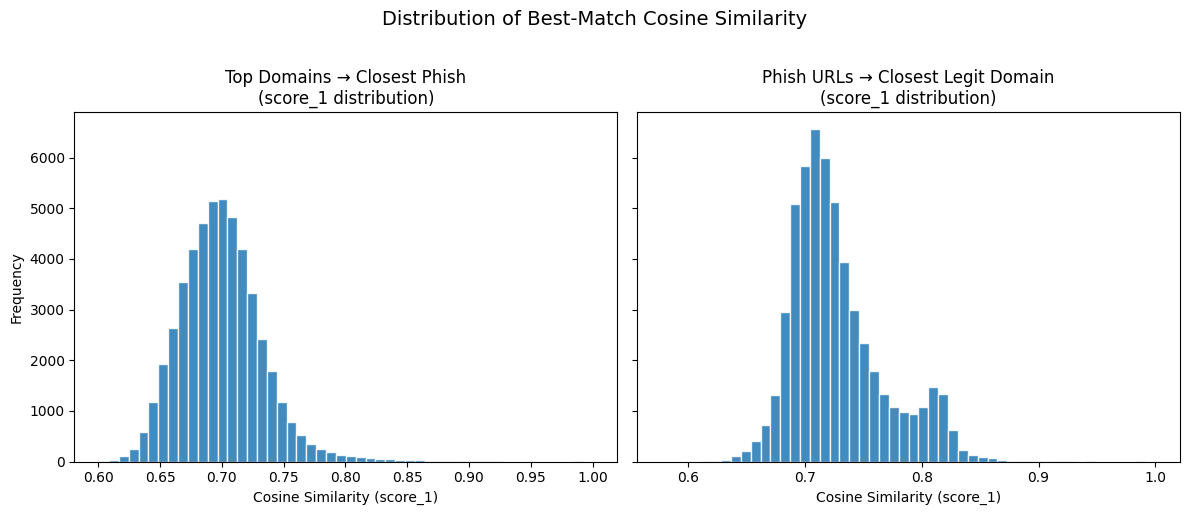

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].hist(df_top["score_1"], bins=50, edgecolor="white", alpha=0.85)
axes[0].set_title("Top Domains → Closest Phish\n(score_1 distribution)")
axes[0].set_xlabel("Cosine Similarity (score_1)")
axes[0].set_ylabel("Frequency")
axes[1].hist(df_phish["score_1"], bins=50, edgecolor="white", alpha=0.85)
axes[1].set_title("Phish URLs → Closest Legit Domain\n(score_1 distribution)")
axes[1].set_xlabel("Cosine Similarity (score_1)")
fig.suptitle("Distribution of Best-Match Cosine Similarity", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Score Distribution Across Top-5 Matches (Box Plots)

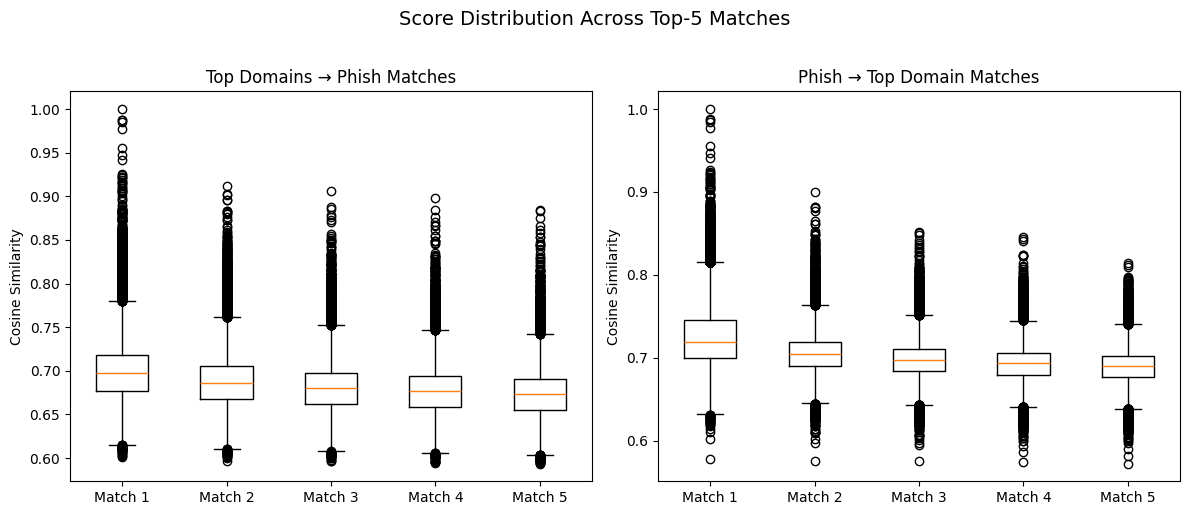

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot([df_top[c].dropna() for c in score_cols],
                tick_labels=[f"Match {i+1}" for i in range(5)])
axes[0].set_title("Top Domains → Phish Matches")
axes[0].set_ylabel("Cosine Similarity")
axes[1].boxplot([df_phish[c].dropna() for c in score_cols],
                tick_labels=[f"Match {i+1}" for i in range(5)])
axes[1].set_title("Phish → Top Domain Matches")
axes[1].set_ylabel("Cosine Similarity")
fig.suptitle("Score Distribution Across Top-5 Matches", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Average Score Drop-off Line Chart

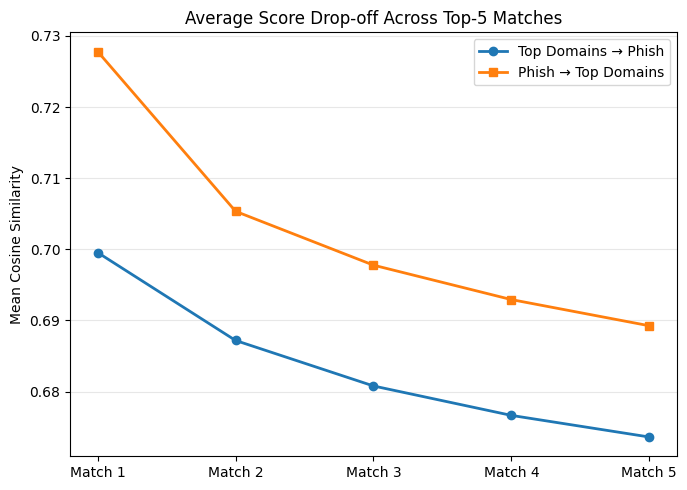

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
x = range(1, 6)
ax.plot(x, means_top.values, "o-", label="Top Domains → Phish", linewidth=2)
ax.plot(x, means_phish.values, "s-", label="Phish → Top Domains", linewidth=2)
ax.set_xticks(list(x))
ax.set_xticklabels([f"Match {i}" for i in x])
ax.set_ylabel("Mean Cosine Similarity")
ax.set_title("Average Score Drop-off Across Top-5 Matches")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Top 20 Phish URLs Most Similar to a Legitimate Domain

In [12]:
# Remove exact overlaps between Tranco-side items and Phish-side items
top_items = set(df_top["item"].astype(str).str.lower())
phish_items = set(df_phish["item"].astype(str).str.lower())
exact_overlap = top_items & phish_items

# Exclude rows where item or any matched domain entry is an exact overlap
mask_overlap = (
    df_phish["item"].astype(str).str.lower().isin(exact_overlap) |
    df_phish[match_cols].apply(lambda c: c.astype(str).str.lower().isin(exact_overlap)).any(axis=1)
)

# Top 20 by strongest nearest-neighbor similarity
top20p = df_phish.loc[~mask_overlap].nlargest(20, "score_1").copy()

# Compact similarity vector for easy scanning
top20p["similarity_vector"] = top20p[score_cols].apply(
    lambda r: "[" + ", ".join(f"{v:.3f}" for v in r.values) + "]", axis=1
)

# Final sorted table
out_tbl = top20p[
    ["item", "match_1", "score_1"]
].rename(columns={"match_1": "closest_real_url"}).sort_values("score_1", ascending=False)

out_tbl = out_tbl.reset_index(drop=True)
out_tbl.index = out_tbl.index + 1

print("Top 20 Phish URLs Most Similar to a Legitimate Domain (table view)")
display(out_tbl)

Top 20 Phish URLs Most Similar to a Legitimate Domain (table view)


,item,closest_real_url,score_1
1,chateauversalles.fr,chateauversailles.fr,0.925930
2,tdsynnexdeveloper.com,tdsynnex.com,0.924352
3,daiwa.jp,daiwa.co.jp,0.922306
4,tronlink.org.uk,tronlink.org,0.922023
5,bradesco.primeoficial.com,bradescoprime.com.br,0.920717
6,sncf-connect.app,sncf-connect.com,0.918135
7,scrtc.weebly.com,scrtc.com,0.915968
8,lassuranceretraite.net,lassuranceretraite.fr,0.914879
9,t-2net.com/?,t-2.net,0.913940
10,hushmail.web.app,hushmail.com,0.912192


## Spread Between Best and 5th-Best Match (score_1 vs score_5)

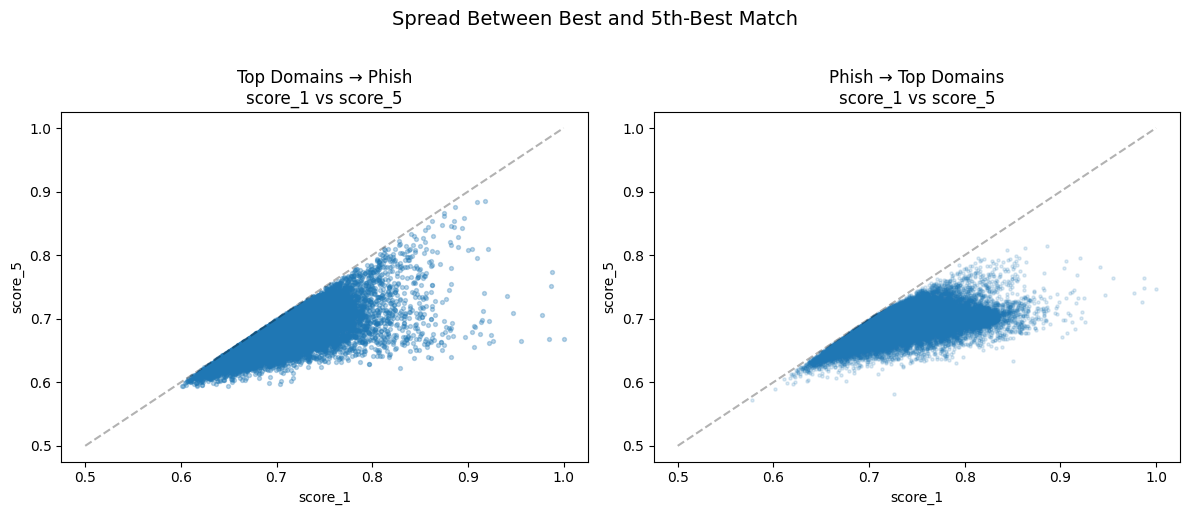

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df_top["score_1"], df_top["score_5"], alpha=0.3, s=8)
axes[0].plot([0.5, 1], [0.5, 1], "k--", alpha=0.3)
axes[0].set_xlabel("score_1")
axes[0].set_ylabel("score_5")
axes[0].set_title("Top Domains → Phish\nscore_1 vs score_5")

axes[1].scatter(df_phish["score_1"], df_phish["score_5"], alpha=0.15, s=5)
axes[1].plot([0.5, 1], [0.5, 1], "k--", alpha=0.3)
axes[1].set_xlabel("score_1")
axes[1].set_ylabel("score_5")
axes[1].set_title("Phish → Top Domains\nscore_1 vs score_5")

fig.suptitle("Spread Between Best and 5th-Best Match", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## CDF of Best-Match Cosine Similarity

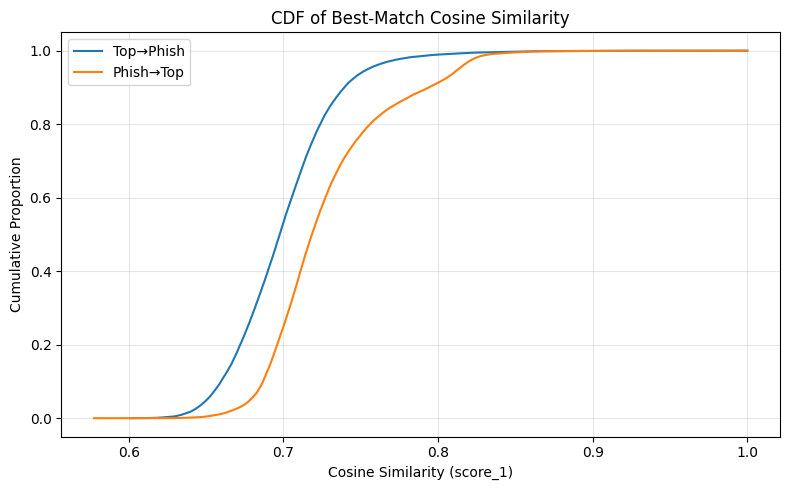

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
for label, series in [("Top→Phish", df_top["score_1"]),
                      ("Phish→Top", df_phish["score_1"])]:
    sorted_s = np.sort(series.dropna())
    cdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
    ax.plot(sorted_s, cdf, label=label, linewidth=1.5)
ax.set_xlabel("Cosine Similarity (score_1)")
ax.set_ylabel("Cumulative Proportion")
ax.set_title("CDF of Best-Match Cosine Similarity")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## References
[1] Gabriela Brezeanu, Alexandru Archip, and Codrut-Georgian Artene. Phish fighter: Self updating machine learning shield against phishing kits based on HTML code analysis. 13:4460–4486.

[2] Bibhu Dash and Meraj Farheen Ansari. An effective cybersecurity awareness training model: First defense of an organizational security strategy. International Research Journal of Engineering and Technology, 9:2395–0056, 04 2022.

[3] Dawn M. Sarno, Maggie W. Harris, and Jeffrey Black. Which phish is captured in the net? understanding phishing susceptibility and individual differences. 37(4):789–803._eprint:onlinelibrary.wiley.com/doi/pdf/10.1002/acp.4075.

[4] Giuseppe Desolda, Francesco Greco, and Luca Vigano. APOLLO: A GPT-based tool to detect phishing emails and generate explanations that warn users. 9(4):EICS003:1–EICS003:33.

[5] Nadjate Saidani, Kamel Adi, and Mohand Saïd Allili. A semantic-based classification approach for an enhanced spam detection. Computers & Security, 94, 2020-07.

[6] Sonowal and Gunikhan. Detecting phishing sms based on multiple correlation algorithms. SN Computer Science, 1, 11 2020.

[7] Panpan Zhang, Jing Ya, Tingwen Liu, Quangang Li, Jinqiao Shi, and Zhaojun Gu. imcircle: Automatic mining of indicators of compromise from the web. In 2019 IEEE  symposium on Computers and Communications (ISCC), 2019.

[8] Rasha Zieni, Luisa Massari, and Maria Carla Calzarossa. Phishing or not phishing? a survey on the detection of phishing websites. 11:18499–18519.

[9] Chugani, Vinod. “What Is Cosine Distance?” Datacamp.com, DataCamp, 28 July 2024, www.datacamp.com/tutorial/cosine-distance.

[10] Cisco Systems, Inc. PhishTank: Join the fight against phishing. phishtank.com, 2026.

[11] Victor Le Pochat, Tom Van Goethem, Samaneh Tajalizadehkhoob, Maciej Korczy´nski, and Wouter Joosen. Tranco: A Research-Oriented Top Sites Ranking Hardened Against Manipulation. In Proceedings of the 26th Annual Network and Distributed System Security Symposium (NDSS), 2019.